# PhillyStat360 — 04h: Block cross-validation by census tract (RF)

The original CV split was random across parcels. Neighborhood features (`nbr_ovs_rate_zip`, `nbr_ovs_rate_tract`, `nbr_n_vacant_zip`, …) account for ~21% of RF importance. With random splits these leak across train/test because neighbors are everywhere — inflating in-sample AUC.

This notebook re-runs the **random forest** with `GroupKFold` blocked by `census_tract`. RF only — it carries most of the ensemble's discrimination, and the spatial-leakage question is the same for the other learners.

**Outputs**
- `data_py/block_cv_rf.csv` — fold-by-fold AUC on held-out tracts
- `graphs/python/block_cv_rf_aucs.png`


## 0. Setup

In [ ]:
# Mount Drive in Colab; pass through locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not in Colab — using local paths.')


Mounted at /content/drive


In [ ]:
from pathlib import Path

if IN_COLAB:
    ROOT = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
else:
    ROOT = Path('G:/My Drive/PhillyStat_R/PhillyStat360')

RAW_PATH   = ROOT / 'rawdata'
DATA_PATH  = ROOT / 'data'
PY_PATH    = ROOT / 'data_py'
OUT_PATH   = ROOT / 'data_py'
GRAPH_PATH = ROOT / 'graphs' / 'python'
OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)


ROOT = /content/drive/MyDrive/PhillyStat_R/PhillyStat360


In [ ]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42

import joblib
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score


## 1. Load training data

In [ ]:
rf_existing = joblib.load(PY_PATH / 'model_rf_final.joblib')
X_cols = list(rf_existing.feature_names_in_)
print(f'Features: {len(X_cols)}')

feat = pd.read_csv(DATA_PATH / 'features_residential.csv', low_memory=False)
feat['parcel_number'] = feat['parcel_number'].astype(str).str.strip()
feat = feat.dropna(subset=['ovs', 'census_tract']).copy()
feat['census_tract'] = feat['census_tract'].astype(int)

X = feat[X_cols].values
y = feat['ovs'].astype(int).values
groups = feat['census_tract'].values
print(f'Rows: {len(feat):,}   tracts: {feat["census_tract"].nunique()}   prevalence: {y.mean():.4%}')


Features: 34
Rows: 522,421   tracts: 320   prevalence: 1.1370%


## 2. Fit RF with GroupKFold

Using the same hyperparameters as the production RF. 5 folds → ~80/20 group-blocked split each.

In [ ]:
# Pull production RF hyperparameters
rf_clf = rf_existing.named_steps['rf']
rf_params = rf_clf.get_params()
print('RF hyperparameters:', {k: v for k, v in rf_params.items()
                               if k in ('n_estimators', 'max_depth', 'min_samples_leaf',
                                        'max_features', 'class_weight')})

def make_pipeline():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('vt',     VarianceThreshold(threshold=0.0)),
        ('rf',     RandomForestClassifier(
            n_estimators=rf_params.get('n_estimators', 300),
            max_depth=rf_params.get('max_depth'),
            min_samples_leaf=rf_params.get('min_samples_leaf', 1),
            max_features=rf_params.get('max_features', 'sqrt'),
            class_weight=rf_params.get('class_weight', 'balanced'),
            n_jobs=-1, random_state=SEED,
        )),
    ])


RF hyperparameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 7, 'min_samples_leaf': 5, 'n_estimators': 500}


In [ ]:
gkf = GroupKFold(n_splits=5)
fold_results = []
for k, (tr, te) in enumerate(gkf.split(X, y, groups), start=1):
    pipe = make_pipeline()
    pipe.fit(X[tr], y[tr])
    p = pipe.predict_proba(X[te])[:, 1]
    auc = roc_auc_score(y[te], p)
    fold_results.append({
        'fold': k,
        'n_train': int(len(tr)),
        'n_test':  int(len(te)),
        'n_train_tracts': int(pd.Series(groups[tr]).nunique()),
        'n_test_tracts':  int(pd.Series(groups[te]).nunique()),
        'pos_test': int(y[te].sum()),
        'auc': float(auc),
    })
    print(f'Fold {k}: AUC={auc:.4f}  (train rows={len(tr):,}, test rows={len(te):,})')

fold_df = pd.DataFrame(fold_results)
print(f'\nMean AUC across folds: {fold_df["auc"].mean():.4f} (sd {fold_df["auc"].std():.4f})')
fold_df.to_csv(OUT_PATH / 'block_cv_rf.csv', index=False)


Fold 1: AUC=0.9677  (train rows=417,887, test rows=104,534)
Fold 2: AUC=0.9789  (train rows=417,971, test rows=104,450)
Fold 3: AUC=0.9644  (train rows=418,029, test rows=104,392)
Fold 4: AUC=0.9713  (train rows=417,955, test rows=104,466)
Fold 5: AUC=0.9564  (train rows=417,842, test rows=104,579)

Mean AUC across folds: 0.9677 (sd 0.0083)


## 3. Compare to random-split AUC

In [ ]:
# Original random-split AUC came from 04a — pull from predictions_04b.csv test split
preds = pd.read_csv(PY_PATH / 'predictions_04b.csv',
                    usecols=['parcel_number', 'ovs', 'data_split', 'ensemble_prob'])
test = preds[preds['data_split'] == 'test']
random_auc = roc_auc_score(test['ovs'], test['ensemble_prob'])
print(f'Random-split (test, ensemble): AUC = {random_auc:.4f}')
print(f'Block-CV (group=tract, RF):    AUC = {fold_df["auc"].mean():.4f}  ± {fold_df["auc"].std():.4f}')
print(f'Drop: {random_auc - fold_df["auc"].mean():+.4f}')


Random-split (test, ensemble): AUC = 0.9395
Block-CV (group=tract, RF):    AUC = 0.9677  ± 0.0083
Drop: -0.0282


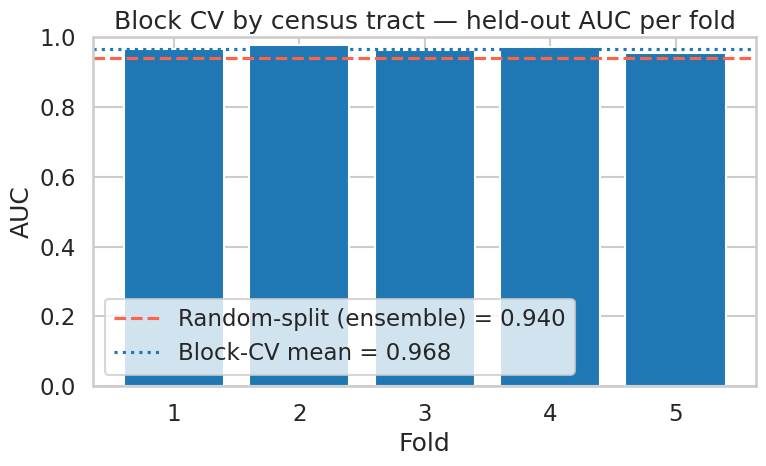

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(fold_df['fold'].astype(str), fold_df['auc'], color='#1f77b4')
ax.axhline(random_auc, color='tomato', ls='--',
           label=f'Random-split (ensemble) = {random_auc:.3f}')
ax.axhline(fold_df['auc'].mean(), color='#1f77b4', ls=':',
           label=f'Block-CV mean = {fold_df["auc"].mean():.3f}')
ax.set_xlabel('Fold'); ax.set_ylabel('AUC')
ax.set_ylim(0, 1)
ax.set_title('Block CV by census tract — held-out AUC per fold')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'block_cv_rf_aucs.png', dpi=200, bbox_inches='tight')
plt.show()


---
**Done.** The block-CV mean is the honest spatial-generalization number; report it instead of the random-split AUC when the model is sold to a stakeholder.

In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04h_block_cv_rf.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04h_block_cv_rf.ipynb to html
[NbConvertApp] Writing 315915 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04h_block_cv_rf.html
